In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx

from circle import Circle
from ray import ray_is_blocked
from visibility import classify_visibility
from graph import build_graph, plot_graph

%matplotlib inline
print("Tudo importado com sucesso!")

Tudo importado com sucesso!


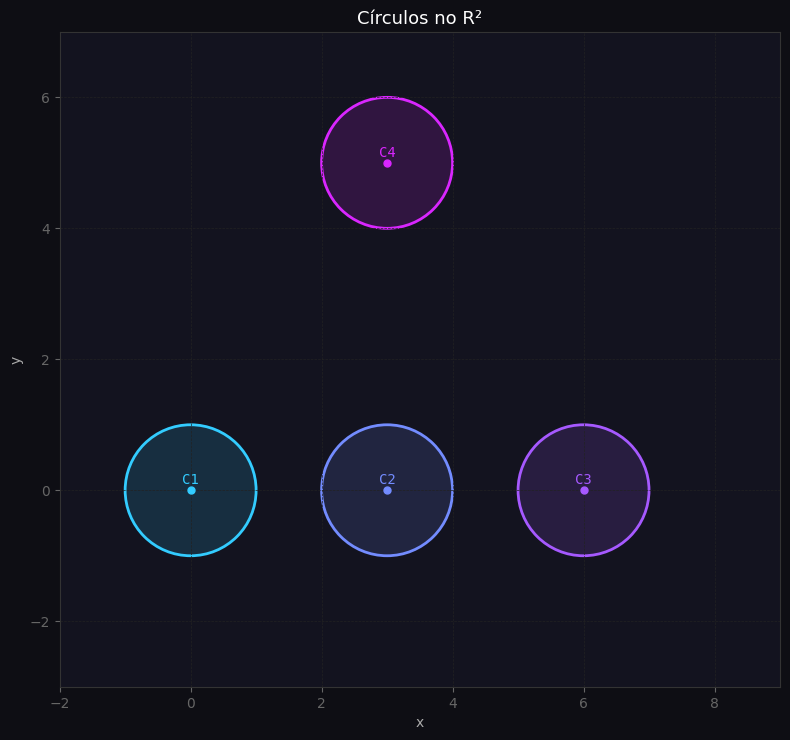

In [2]:
# Criando os círculos
c1 = Circle(center=(0.0, 0.0), radius=1.0, label="C1")
c2 = Circle(center=(3.0, 0.0), radius=1.0, label="C2")  # obstáculo
c3 = Circle(center=(6.0, 0.0), radius=1.0, label="C3")  # bloqueado por C2
c4 = Circle(center=(3.0, 5.0), radius=1.0, label="C4")  # livre

circles = [c1, c2, c3, c4]

# Visualizando só os círculos (sem o grafo ainda)
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("#0e0e14")
ax.set_facecolor("#13131f")

colors = plt.cm.cool([0.2, 0.45, 0.65, 0.85])
for circle, color in zip(circles, colors):
    patch = patches.Circle(
        circle.center, circle.radius,
        facecolor=(*color[:3], 0.15),
        edgecolor=color, linewidth=2
    )
    ax.add_patch(patch)
    ax.plot(*circle.center, "o", color=color, markersize=5)
    ax.text(circle.cx, circle.cy + circle.radius * 0.1,
            circle.label, color=color, fontsize=10,
            ha="center", fontfamily="monospace")

ax.set_xlim(-2, 9)
ax.set_ylim(-3, 7)
ax.set_aspect("equal")
ax.set_title("Círculos no R²", color="white", fontsize=13)
ax.set_xlabel("x", color="#aaa")
ax.set_ylabel("y", color="#aaa")
ax.tick_params(colors="#666")
ax.grid(True, color="#222", linewidth=0.5, linestyle="--")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

plt.tight_layout()
plt.show()


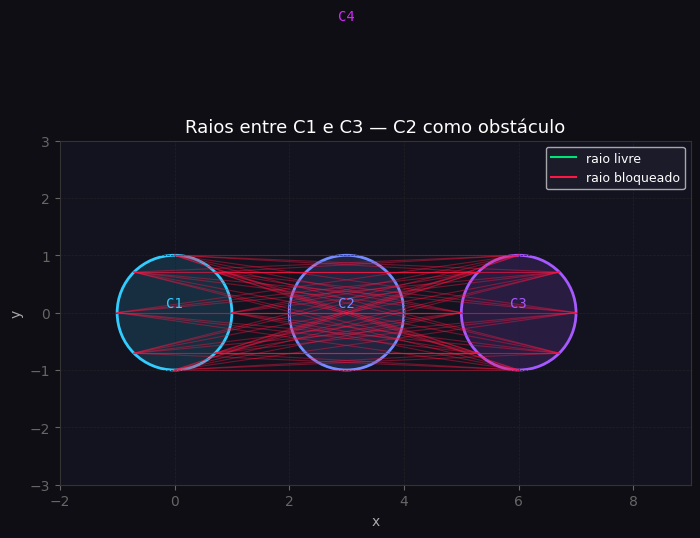

In [3]:
# Visualizando raios entre C1 e C3 (com C2 como obstáculo)
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#0e0e14")
ax.set_facecolor("#13131f")

# Amostra poucos pontos para visualizar os raios claramente
n = 8
pts_a = c1.sample_boundary(n)
pts_b = c3.sample_boundary(n)
obstacles = [c2]  # apenas C2 como obstáculo

for pa in pts_a:
    for pb in pts_b:
        blocked = ray_is_blocked(tuple(pa), tuple(pb), obstacles)
        color = "#ff1744" if blocked else "#00e676"
        alpha = 0.4 if blocked else 0.6
        ax.plot([pa[0], pb[0]], [pa[1], pb[1]],
                color=color, linewidth=0.8, alpha=alpha)

# Desenha os círculos
for circle, color in zip(circles, plt.cm.cool([0.2, 0.45, 0.65, 0.85])):
    patch = patches.Circle(
        circle.center, circle.radius,
        facecolor=(*color[:3], 0.15),
        edgecolor=color, linewidth=2
    )
    ax.add_patch(patch)
    ax.text(circle.cx, circle.cy + circle.radius * 0.1,
            circle.label, color=color, fontsize=10,
            ha="center", fontfamily="monospace")

ax.plot([], [], color="#00e676", label="raio livre")
ax.plot([], [], color="#ff1744", label="raio bloqueado")
ax.legend(facecolor="#1e1e2e", labelcolor="white", fontsize=9)

ax.set_xlim(-2, 9)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title("Raios entre C1 e C3 — C2 como obstáculo", color="white", fontsize=13)
ax.set_xlabel("x", color="#aaa")
ax.set_ylabel("y", color="#aaa")
ax.tick_params(colors="#666")
ax.grid(True, color="#222", linewidth=0.5, linestyle="--")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

plt.tight_layout()
plt.show()

Construindo grafo de visibilidade...

Arestas e pesos:
  C1 — C2: 0 (visível)
  C1 — C3: 2 (bloqueado)
  C1 — C4: 0 (visível)
  C2 — C3: 0 (visível)
  C2 — C4: 0 (visível)
  C3 — C4: 0 (visível)


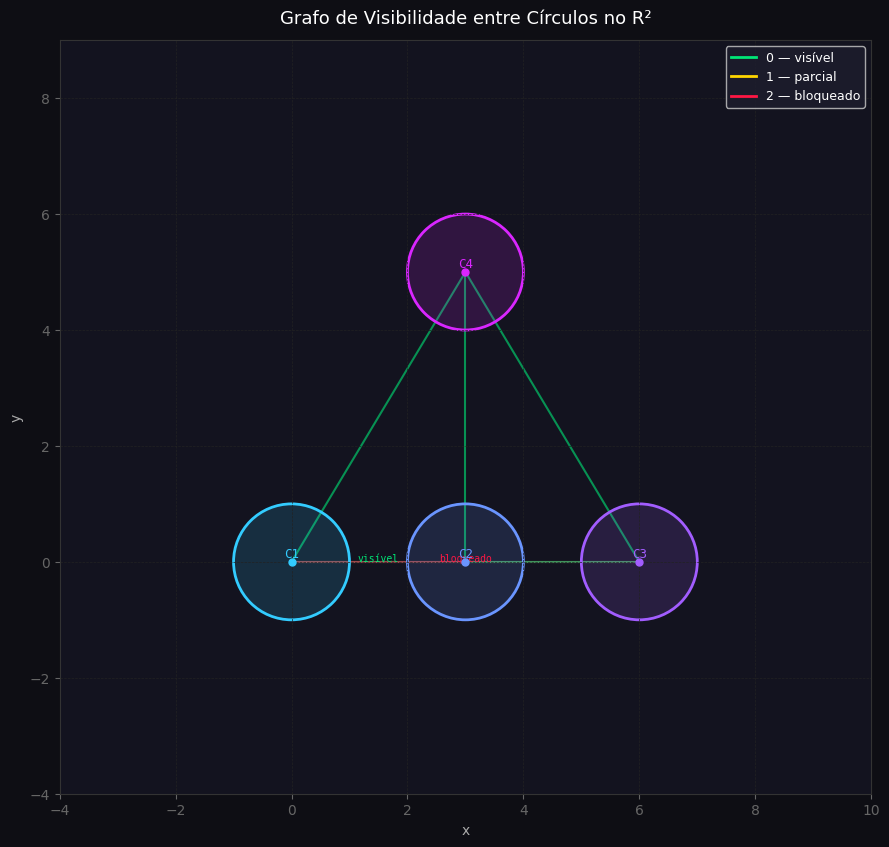

In [4]:
# Construindo o grafo completo
print("Construindo grafo de visibilidade...")
G = build_graph(circles, n_samples=32)

print("\nArestas e pesos:")
for i, j, data in G.edges(data=True):
    w = data["weight"]
    status = ["visível", "parcial", "bloqueado"][w]
    print(f"  {circles[i].label} — {circles[j].label}: {w} ({status})")

# Plotando o grafo
plot_graph(circles, G)

In [5]:
print("=== Resumo do Grafo de Visibilidade ===\n")
print(f"Número de nós  : {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}\n")

for i, j, data in G.edges(data=True):
    w = data["weight"]
    status = ["visível", "parcial", "bloqueado"][w]
    simbolo = ["✅", "⚠️", "❌"][w]
    print(f"  {simbolo} {circles[i].label} — {circles[j].label}: {status}")

=== Resumo do Grafo de Visibilidade ===

Número de nós  : 4
Número de arestas: 6

  ✅ C1 — C2: visível
  ❌ C1 — C3: bloqueado
  ✅ C1 — C4: visível
  ✅ C2 — C3: visível
  ✅ C2 — C4: visível
  ✅ C3 — C4: visível
